# 1. 数据清洗
我们需要从数据集 alzheimers_disease_data.csv 中去掉不需要的特征，例如患者ID（PatientID）和主治医师（DoctorInCharge），因为这些特征与诊断无关。

为了处理推理时的缺失值，我们需要保存训练集中所有特征的中位数值到文件 medians.pkl，以便后续使用。

接下来，将数据分为特征（X）和标签（y），假设标签列是 Diagnosis。

In [1]:
import pandas as pd
import pickle

# 加载数据集
data = pd.read_csv('alzheimers_disease_data.csv')

# 去掉不需要的特征
data = data.drop(['PatientID', 'DoctorInCharge'], axis=1)

# 检查数据是否加载正确
print("数据预览：")
print(data.head())


# 计算每个特征的中位数
medians = data.median()

# 保存中位数到文件
with open('medians.pkl', 'wb') as f:
    pickle.dump(medians, f)

# 分离特征和标签
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# 将数据集分为训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Assuming X_train is your training DataFrame
# Save the feature names to a file
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)


数据预览：
   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0   73       0          0               2  22.927749        0   
1   89       0          0               0  26.827681        0   
2   73       0          3               1  17.795882        0   
3   74       1          0               1  33.800817        1   
4   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0              6.518877                 0                   0  1.725883   
1 

# 2. 模型训练

我们将尝试多种模型（XGBoost、CatBoost、Gradient Boosting、MLP等）并进行融合，重点优化召回率（recall），因为在医疗场景中漏诊的代价较高。

## XGBoost

In [2]:
import xgboost as xgb
from sklearn.metrics import recall_score, classification_report

# 初始化XGBoost模型，优化召回率
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=2,  # 增加正类权重以提升召回率
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    random_state=420
)

# 训练模型
xgb_model.fit(X_train, y_train)

# 在测试集上预测
y_pred_xgb = xgb_model.predict(X_test)

# 评估模型性能
print("XGBoost 模型评估：")
print("召回率:", recall_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost 模型评估：
召回率: 0.95
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       270
           1       0.96      0.95      0.96       160

    accuracy                           0.97       430
   macro avg       0.97      0.96      0.97       430
weighted avg       0.97      0.97      0.97       430



## Catboost

In [3]:
from catboost import CatBoostClassifier

# 初始化CatBoost模型
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    class_weights=[1, 2],  # 调整类别权重以提升召回率
    random_state=42,
    verbose=0  # 关闭训练日志
)

# 训练模型
cat_model.fit(X_train, y_train)

# 预测
y_pred_cat = cat_model.predict(X_test)

# 评估
print("CatBoost 模型评估：")
print("召回率:", recall_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

CatBoost 模型评估：
召回率: 0.9625
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       270
           1       0.96      0.96      0.96       160

    accuracy                           0.97       430
   macro avg       0.97      0.97      0.97       430
weighted avg       0.97      0.97      0.97       430



## Gradient Boosting 模型

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

# 初始化Gradient Boosting模型
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 训练模型
gb_model.fit(X_train, y_train)

# 预测
y_pred_gb = gb_model.predict(X_test)

# 评估
print("Gradient Boosting 模型评估：")
print("召回率:", recall_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting 模型评估：
召回率: 0.95
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       270
           1       0.96      0.95      0.95       160

    accuracy                           0.97       430
   macro avg       0.96      0.96      0.96       430
weighted avg       0.97      0.97      0.97       430



## MLP

In [5]:
from sklearn.neural_network import MLPClassifier

# 初始化MLP模型
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    learning_rate_init=0.01,
    random_state=42
)

# 训练模型
mlp_model.fit(X_train, y_train)

# 预测
y_pred_mlp = mlp_model.predict(X_test)

# 评估
print("MLP 模型评估：")
print("召回率:", recall_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP 模型评估：
召回率: 0.83125
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       270
           1       0.68      0.83      0.75       160

    accuracy                           0.79       430
   macro avg       0.78      0.80      0.79       430
weighted avg       0.81      0.79      0.80       430



## 模型融合（软投票）

In [6]:
from sklearn.ensemble import VotingClassifier

# 初始化投票分类器
voting_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('cat', cat_model),
        ('gb', gb_model),
        ('mlp', mlp_model)
    ],
    voting='soft'  # 软投票基于概率
)

# 训练融合模型
voting_model.fit(X_train, y_train)

# 预测
y_pred_voting = voting_model.predict(X_test)

# 评估
print("Voting Classifier 模型评估：")
print("召回率:", recall_score(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))

KeyboardInterrupt: 

## 画图咯

c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAP

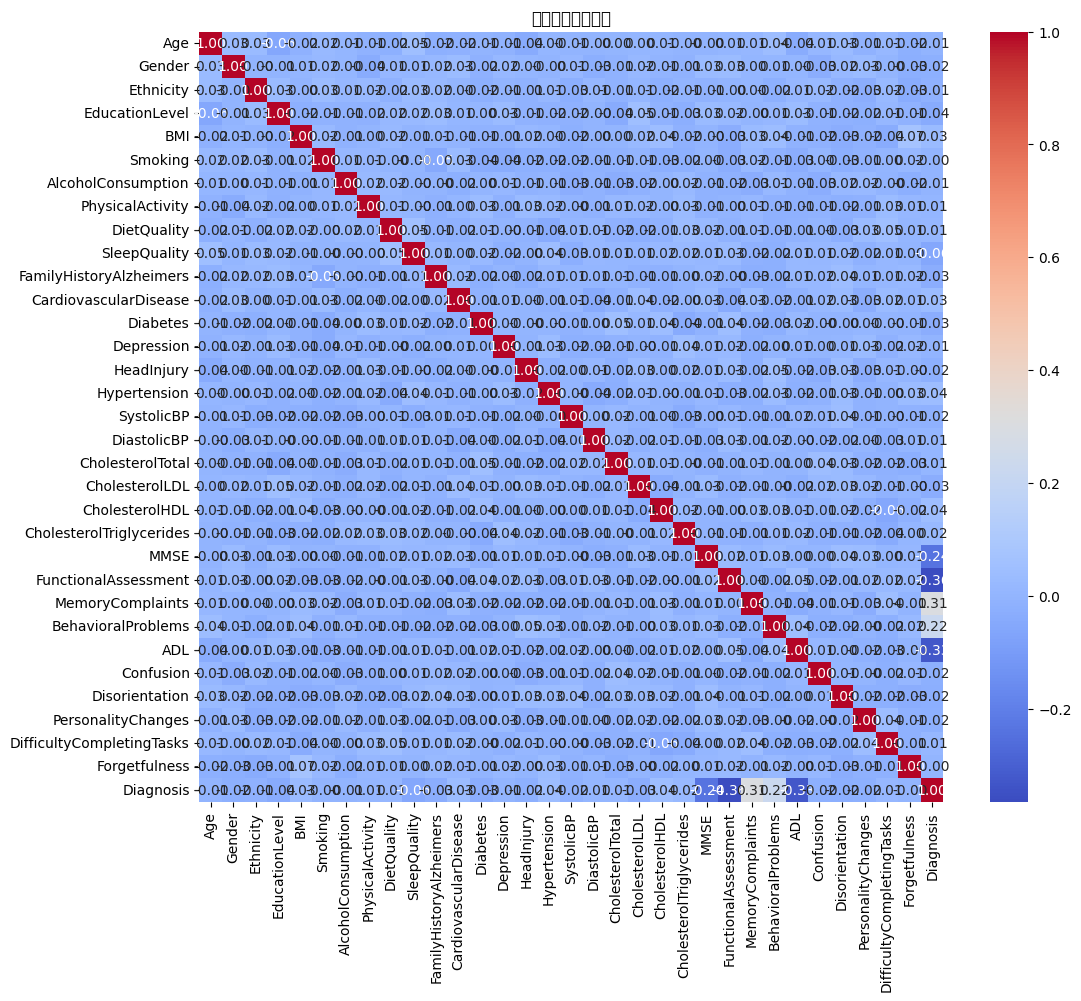

c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAP

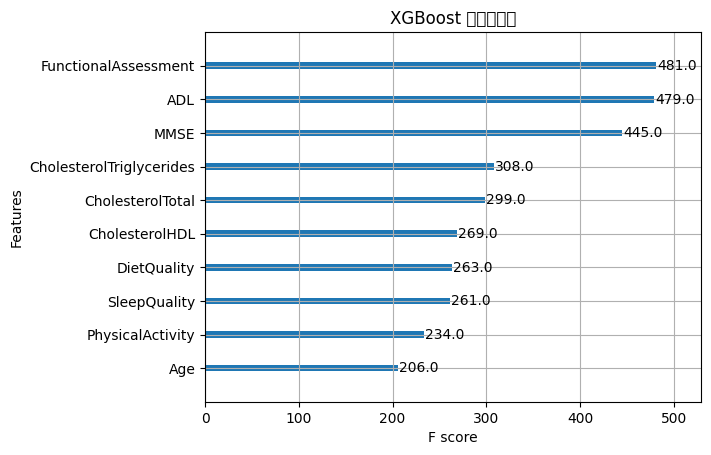

c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAP

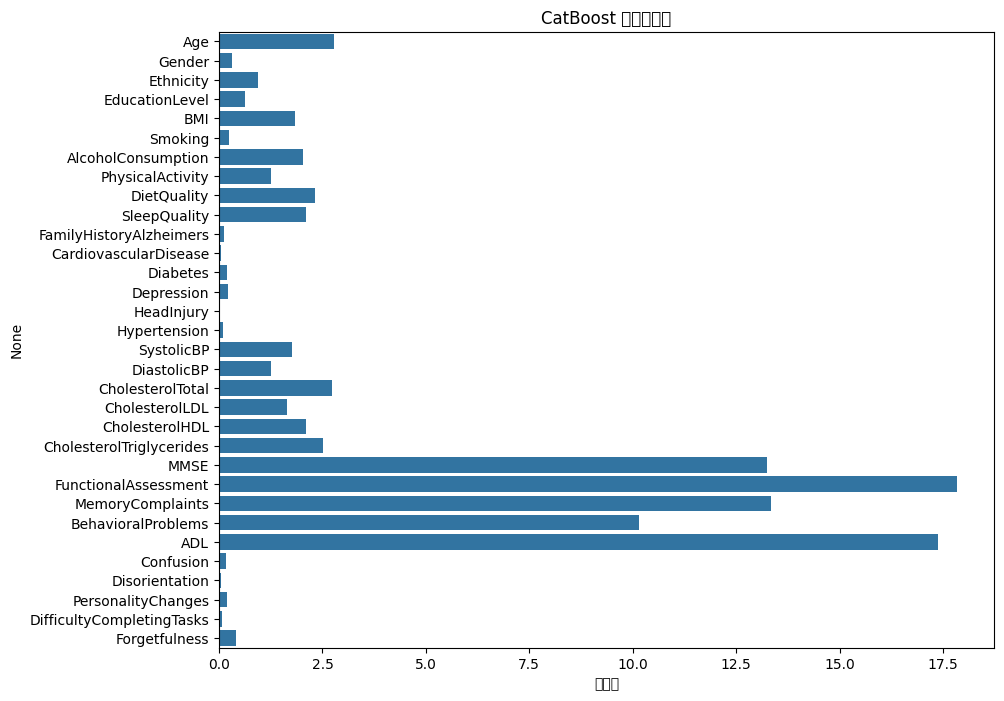

c:\Users\lenovo\.conda\envs\Jyun\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.01,
              max_iter=500, random_state=42)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 计算特征与结果的相关性
corr = data.corr()

# 绘制热力图
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("特征相关性热力图")
plt.show()

# 绘制XGBoost特征重要性
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title("XGBoost 特征重要性")
plt.show()

# 获取CatBoost特征重要性
feature_importance = cat_model.get_feature_importance()
feature_names = X.columns

# 绘制条形图
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance, y=feature_names)
plt.title("CatBoost 特征重要性")
plt.xlabel("重要性")
plt.show()

import shap

# 创建SHAP解释器
explainer = shap.Explainer(mlp_model, X_train)
shap_values = explainer(X_test)

# 绘制SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

## 保存模型

In [ ]:
# 保存XGBoost模型
xgb_model.save_model('xgb_model.json')

# 保存CatBoost模型
cat_model.save_model('cat_model.cbm')

# 保存Gradient Boosting模型
with open('gb_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

# 保存MLP模型
with open('mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp_model, f)

# 保存Voting模型
with open('voting_model.pkl', 'wb') as f:
    pickle.dump(voting_model, f)